In [3]:
import pandas as pd
import re

# 1. Buka data mentah ASLI
df_raw = pd.read_csv('master_chat_wa.csv')

# 2. Filter Chat Admin dan Media
nomor_admin = 6285752887496 # Nomor Anugerah Computer
df_pelanggan = df_raw[df_raw['Phone Number'] != nomor_admin].copy()
df_pelanggan = df_pelanggan.dropna(subset=['Message Body'])
df_pelanggan = df_pelanggan[~df_pelanggan['Message Body'].astype(str).str.contains('【IMAGE】|【VIDEO】|【STICKER】')]

# 3. Fungsi Membersihkan Teks
def bersihkan_teks(teks):
    teks = str(teks).lower()
    teks = re.sub(r'[^a-z0-9\s]', '', teks) 
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks

df_pelanggan['Teks_Bersih'] = df_pelanggan['Message Body'].apply(bersihkan_teks)

# 4. Fungsi Auto-Labeling (Biar kamu gak ngetik dari nol)
def auto_label(teks):
    teks = str(teks)
    if any(kata in teks for kata in ['status', 'sampai mana', 'kapan', 'progress', 'udah kelar', 'udah jadi', 'selesai']):
        return 'tanya_status'
    elif any(kata in teks for kata in ['batal', 'cancel', 'gak jadi', 'ndak usah', 'sik jadi', 'gausah']):
        return 'batal'
    elif any(kata in teks for kata in ['setuju', 'oke', 'lanjut', 'gas', 'deal', 'sikat', 'kerjakan', 'ok', 'sip']):
        return 'setuju'
    elif any(kata in teks for kata in ['garansi', 'ram', 'biaye', 'harga', 'bisa nego', 'jam buka', 'lcd', 'biaya']):
        return 'umum_teknis'
    else:
        return 'TIDAK_DIKETAHUI' # Chat yang bahasanya aneh akan masuk sini

df_pelanggan['Label'] = df_pelanggan['Teks_Bersih'].apply(auto_label)

# 5. Ekspor hasilnya ke Excel/CSV agar bisa kamu periksa
df_pelanggan[['Formatted Name', 'Message Body', 'Teks_Bersih', 'Label']].to_csv('data_asli_terlabeli_sementara.csv', index=False)

print(f"Total data siap dicek: {len(df_pelanggan)} baris.")
print("File 'data_asli_terlabeli_sementara.csv' sudah dibuat!")

Total data siap dicek: 1478 baris.
File 'data_asli_terlabeli_sementara.csv' sudah dibuat!


In [6]:
# Fungsi Auto-Labeling berbasis Rule/Keyword Matching
def auto_label(teks):
    teks = str(teks)
    if any(kata in teks for kata in ['status', 'sampai mana', 'kapan', 'progress', 'kelar', 'selesai', 'belum']):
        return 'tanya_status'
    elif any(kata in teks for kata in ['batal', 'cancel', 'tidak jadi', 'tidak usah', 'tarik']):
        return 'batal'
    elif any(kata in teks for kata in ['setuju', 'oke', 'lanjut', 'gas', 'deal', 'sikat', 'kerja', 'ok', 'sip', 'ya']):
        return 'setuju'
    elif any(kata in teks for kata in ['garansi', 'ram', 'biaya', 'harga', 'nego', 'jam', 'buka', 'lcd', 'ganti']):
        return 'umum_teknis'
    else:
        return 'TIDAK_DIKETAHUI'

# Terapkan Labeling ke df_pelanggan yang sudah ada
df_pelanggan['Label'] = df_pelanggan['Teks_Bersih'].apply(auto_label)

# Filter hanya data yang berhasil dilabeli untuk dilatih mesin
df_final = df_pelanggan[df_pelanggan['Label'] != 'TIDAK_DIKETAHUI'].copy()

# Ekspor untuk bukti di Bab 3 (Sebagai Ground Truth)
df_final[['Message Body', 'Teks_Bersih', 'Label']].to_csv('dataset_siap_latih.csv', index=False)
print(f"Data siap latih: {len(df_final)} baris.")

Data siap latih: 1042 baris.


In [8]:
import fasttext
import numpy as np

# 1. Simpan teks bersih ke file .txt untuk dibaca oleh fasttext
with open('corpus_skripsi.txt', 'w', encoding='utf-8') as f:
    for text in df_final['Teks_Bersih']:
        f.write(text + '\n')

# 2. Melatih model FastText (Word Embedding)
# Menggunakan model 'skipgram', dimensi vektor 100, ngram karakter 3-6 (sangat bagus untuk typo)
print("Melatih model FastText...")
ft_model = fasttext.train_unsupervised('corpus_skripsi.txt', model='skipgram', dim=100, minn=3, maxn=6, epoch=50)

# 3. Sentence Embedding (Ekstraksi ke Vektor Kalimat)
# fasttext-wheel memiliki fungsi bawaan .get_sentence_vector() yang otomatis menghitung rata-rata (mean)
X = np.array([ft_model.get_sentence_vector(text) for text in df_final['Teks_Bersih']])
y = df_final['Label']

print("Dimensi Matriks Fitur (X):", X.shape)

Melatih model FastText...
Dimensi Matriks Fitur (X): (1042, 100)


In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
import joblib

# Tahap 5: Pembagian Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tahap 6: Hyperparameter Tuning SVM
print("Mencari parameter SVM terbaik (Grid Search)...")
param_grid = {
    'C': [0.1, 1, 10, 100],          # Regularisasi
    'kernel': ['linear', 'rbf'],     # Jenis garis pemisah
    'gamma': ['scale', 'auto']       # Koefisien untuk RBF
}

# Inisialisasi SVM (wajib probability=True agar bisa fallback ke LLM di Laravel)
svm_base = SVC(probability=True, random_state=42)

# Jalankan pencarian
grid_search = GridSearchCV(estimator=svm_base, param_grid=param_grid, cv=5, verbose=1, scoring='f1_macro')
grid_search.fit(X_train, y_train)

# Ambil model terbaik
best_svm_model = grid_search.best_estimator_
print(f"Parameter SVM Terbaik: {grid_search.best_params_}")

Mencari parameter SVM terbaik (Grid Search)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Parameter SVM Terbaik: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

      setuju       0.88      1.00      0.94       183
tanya_status       1.00      0.09      0.17        11
 umum_teknis       0.00      0.00      0.00        15

    accuracy                           0.88       209
   macro avg       0.63      0.36      0.37       209
weighted avg       0.82      0.88      0.83       209



c:\Users\peno\anaconda3\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\peno\anaconda3\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\peno\anaconda3\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

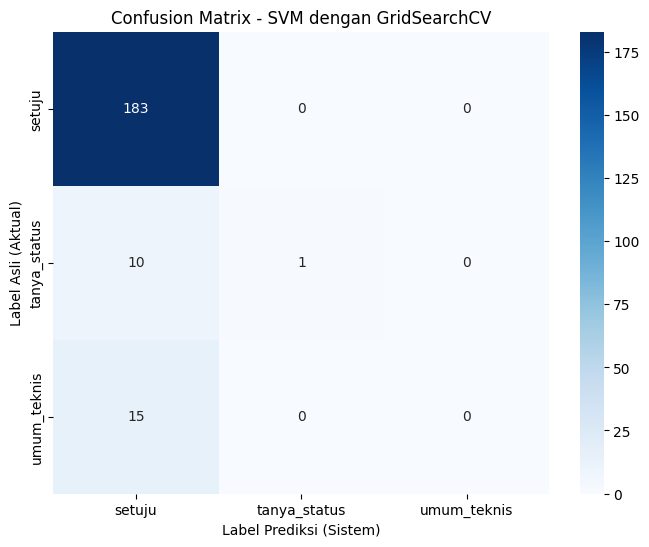

✅ SELESAI! Model FastText (.bin) dan SVM (.joblib) siap dipasang di FastAPI.


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pengujian pada Data Uji
y_pred = best_svm_model.predict(X_test)

# 2. Metriks Evaluasi
print("================ CLASSIFICATION REPORT ================")
print(classification_report(y_test, y_pred))
print("=======================================================")

# 3. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_svm_model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_svm_model.classes_, 
            yticklabels=best_svm_model.classes_)
plt.title('Confusion Matrix - SVM dengan GridSearchCV')
plt.ylabel('Label Asli (Aktual)')
plt.xlabel('Label Prediksi (Sistem)')
plt.show()

# 4. Simpan Model untuk Microservice FastAPI
# Simpan model FastText (.bin) dan model SVM (.joblib)
ft_model.save_model("fasttext_model.bin")
joblib.dump(best_svm_model, 'svm_model.joblib')

print("✅ SELESAI! Model FastText (.bin) dan SVM (.joblib) siap dipasang di FastAPI.")